In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from pathlib import Path

In [2]:
df = pd.read_csv("../data/processed/dk2_merged_price_weather_energy.csv")

df["HourUTC"] = pd.to_datetime(df["HourUTC"])
df["HourDK"] = pd.to_datetime(df["HourDK"])

df = df.sort_values("HourUTC").reset_index(drop=True)

print("Rows:", len(df))
print("Date range:", df["HourUTC"].min(), "→", df["HourUTC"].max())
print("Missing values:", df.isna().sum().sum())

df.head()

Rows: 9824
Date range: 2024-08-17 06:00:00 → 2025-09-30 13:00:00
Missing values: 0


,HourUTC,HourDK,PriceArea,SpotPriceEUR,hour,day_of_week,month,year,is_weekend,price_lag_24h,...,offshore_wind_mwh,onshore_wind_mwh,solar_mwh,total_wind_mwh,renewable_generation_mwh,net_load_mwh,ExchangeSE_MWh,ExchangeGE_MWh,ExchangeGreatBelt_MWh,PowerToHeatMWh
0,2024-08-17 06:00:00,2024-08-17 08:00:00,DK2,103.430000,8,5,8,2024,1,124.830002,...,139.575607,12.631012,290.954754,152.206619,443.161373,913.084285,1004.938750,-542.164000,181.2,32.783193
1,2024-08-17 07:00:00,2024-08-17 09:00:00,DK2,84.000000,9,5,8,2024,1,100.949997,...,111.449682,14.223518,464.444211,125.673200,590.117411,897.563125,1164.431492,-839.658984,202.5,24.287895
2,2024-08-17 08:00:00,2024-08-17 10:00:00,DK2,69.489998,10,5,8,2024,1,76.150002,...,86.846481,11.792317,592.522881,98.638798,691.161679,871.185718,1220.923492,-943.107016,244.5,15.592138
3,2024-08-17 09:00:00,2024-08-17 11:00:00,DK2,54.160000,11,5,8,2024,1,59.830002,...,56.012000,14.692761,641.920324,70.704761,712.625085,884.160102,1320.748250,-959.805000,171.9,14.801758
4,2024-08-17 10:00:00,2024-08-17 12:00:00,DK2,46.830002,12,5,8,2024,1,50.680000,...,35.773500,14.832262,675.559553,50.605762,726.165315,868.566350,1008.507250,-865.089992,340.9,12.442353


In [3]:
horizon = 24

df["target_24h_ahead"] = df["SpotPriceEUR"].shift(-horizon)
df = df.dropna(subset=["target_24h_ahead"]).reset_index(drop=True)

print("Rows after target:", len(df))

Rows after target: 9800


In [4]:
target_col = "target_24h_ahead"

calendar_features = [
    "hour",
    "day_of_week",
    "month",
    "year",
    "is_weekend",
]

price_features = [
    "SpotPriceEUR",
    "price_lag_24h",
    "price_lag_48h",
    "price_lag_168h",
    "price_rolling_mean_24h",
    "price_rolling_std_24h",
    "price_rolling_mean_168h",
    "price_rolling_std_168h",
]

weather_features = [
    "temperature_2m",
    "wind_speed_10m",
    "wind_speed_100m",
    "cloud_cover",
    "shortwave_radiation",
]

energy_features = [
    "GrossConsumptionMWh",
    "CentralPowerMWh",
    "LocalPowerMWh",
    "CommercialPowerMWh",
    "offshore_wind_mwh",
    "onshore_wind_mwh",
    "solar_mwh",
    "total_wind_mwh",
    "renewable_generation_mwh",
    "net_load_mwh",
    "ExchangeSE_MWh",
    "ExchangeGE_MWh",
    "ExchangeGreatBelt_MWh",
    "PowerToHeatMWh",
]

In [5]:
feature_sets = {
    "calendar_only": calendar_features,
    "price_only": price_features,
    "price_calendar": price_features + calendar_features,
    "price_weather": price_features + calendar_features + weather_features,
    "price_energy": price_features + calendar_features + energy_features,
    "all_features": price_features + calendar_features + weather_features + energy_features,
}

In [6]:
for name, features in feature_sets.items():
    missing = [col for col in features if col not in df.columns]
    print(name, "missing:", missing)

calendar_only missing: []
price_only missing: []
price_calendar missing: []
price_weather missing: []
price_energy missing: []
all_features missing: []


In [25]:
size = int(len(df) * 0.7)

train = df.iloc[:size].copy()
test = df.iloc[size:].copy()

print("Train:", train["HourUTC"].min(), "→", train["HourUTC"].max(), len(train))
print("Test:", test["HourUTC"].min(), "→", test["HourUTC"].max(), len(test))


Train: 2024-08-17 06:00:00 → 2025-05-30 01:00:00 6860
Test: 2025-05-30 02:00:00 → 2025-09-29 13:00:00 2940


In [26]:
def evaluate_forecast(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return mae, rmse

In [28]:
results = []
predictions = test[["HourUTC", "HourDK", "SpotPriceEUR", target_col]].copy()

for set_name, features in feature_sets.items():
    X_train = train[features]
    y_train = train[target_col]

    X_test = test[features]
    y_test = test[target_col]

    model = XGBRegressor(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1,
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae, rmse = evaluate_forecast(y_test, y_pred)

    results.append({
        "feature_set": set_name,
        "n_features": len(features),
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2),
    })

    predictions[f"pred_{set_name}"] = y_pred

results_df = pd.DataFrame(results).sort_values("MAE").reset_index(drop=True)

results_df

,feature_set,n_features,MAE,RMSE
0,all_features,32,25.05,34.41
1,price_calendar,13,25.13,35.02
2,price_energy,27,25.15,34.67
3,price_weather,18,25.61,34.84
4,price_only,8,26.62,36.97
5,calendar_only,5,28.00,37.72


In [29]:
baseline_mae, baseline_rmse = evaluate_forecast(
    test[target_col],
    test["SpotPriceEUR"]
)

baseline_row = pd.DataFrame([{
    "feature_set": "current_price_baseline",
    "n_features": 1,
    "MAE": round(baseline_mae, 2),
    "RMSE": round(baseline_rmse, 2),
}])

results_with_baseline = pd.concat(
    [results_df, baseline_row],
    ignore_index=True
).sort_values("MAE").reset_index(drop=True)

results_with_baseline


,feature_set,n_features,MAE,RMSE
0,all_features,32,25.05,34.41
1,price_calendar,13,25.13,35.02
2,price_energy,27,25.15,34.67
3,price_weather,18,25.61,34.84
4,price_only,8,26.62,36.97
5,calendar_only,5,28.00,37.72
6,current_price_baseline,1,28.30,42.29


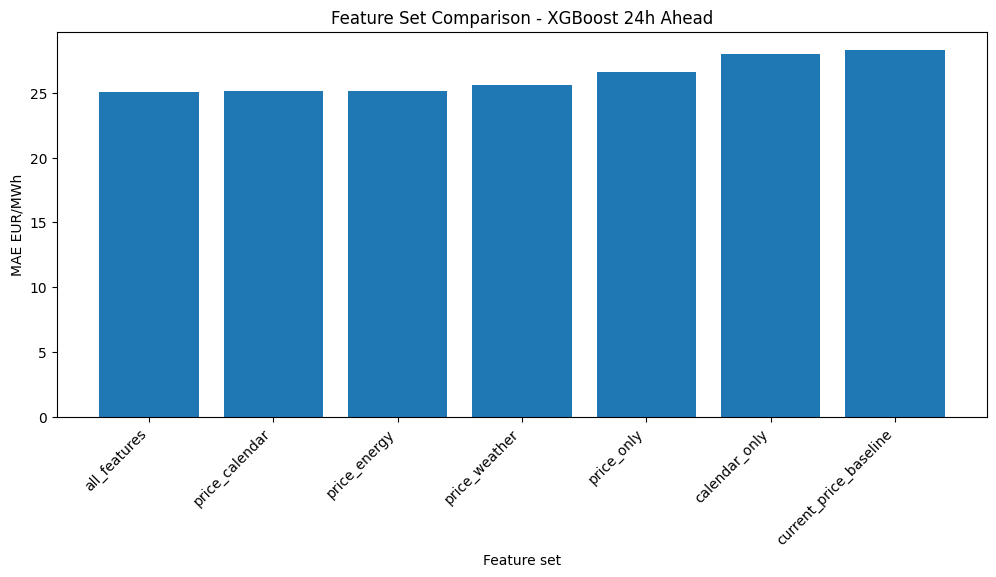

In [30]:
plt.figure(figsize=(12, 5))

plt.bar(
    results_with_baseline["feature_set"],
    results_with_baseline["MAE"]
)

plt.title("Feature Set Comparison - XGBoost 24h Ahead")
plt.xlabel("Feature set")
plt.ylabel("MAE EUR/MWh")
plt.xticks(rotation=45, ha="right")
plt.show()

In [34]:
best_feature_set = results_df.iloc[0]["feature_set"]
best_features = feature_sets[best_feature_set]

print("Best feature set:", best_feature_set)
print("Number of features:", len(best_features))

Best feature set: all_features
Number of features: 32


In [35]:
X_train = train[best_features]
y_train = train[target_col]

X_test = test[best_features]
y_test = test[target_col]

best_model = XGBRegressor(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1,
)

best_model.fit(X_train, y_train)

importance = pd.DataFrame({
    "feature": best_features,
    "importance": best_model.feature_importances_,
}).sort_values("importance", ascending=False)

importance.head(20)

,feature,importance
0,SpotPriceEUR,0.210432
27,net_load_mwh,0.094675
17,shortwave_radiation,0.078709
21,CommercialPowerMWh,0.058811
24,solar_mwh,0.047549
3,price_lag_168h,0.043048
30,ExchangeGreatBelt_MWh,0.036263
10,month,0.032785
22,offshore_wind_mwh,0.026273
9,day_of_week,0.024691


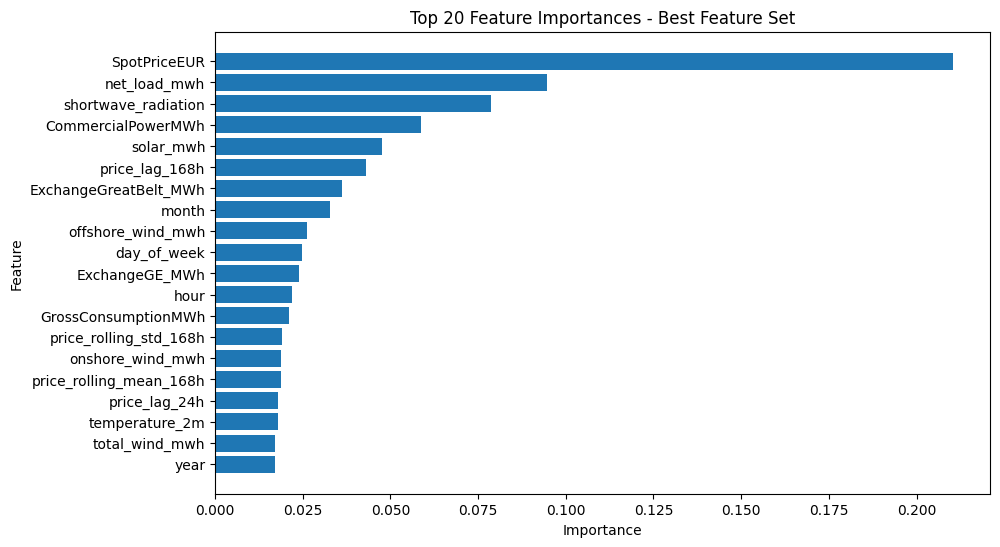

In [36]:
top_importance = importance.head(20)

plt.figure(figsize=(10, 6))
plt.barh(
    top_importance["feature"][::-1],
    top_importance["importance"][::-1]
)
plt.title("Top 20 Feature Importances - Best Feature Set")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [37]:
reports_dir = Path("../reports")
reports_dir.mkdir(parents=True, exist_ok=True)

results_with_baseline.to_csv(
    "../reports/feature_set_comparison_DK2.csv",
    index=False
)

predictions.to_csv(
    "../reports/feature_set_predictions_DK2.csv",
    index=False
)

importance.to_csv(
    "../reports/best_feature_set_importance_DK2.csv",
    index=False
)

## Conclusion

This notebook compares different feature groups for 24-hour-ahead DK2 electricity price forecasting.

The best-performing setup was the full feature set, including historical prices, calendar variables, weather data and energy fundamentals. However, the improvement over the price + calendar feature set was small.

This suggests that most of the predictive signal comes from historical prices and calendar structure, while weather and energy fundamentals provide additional but moderate value.

For the next stages of the project, the full feature set will be used as the main research feature set, while price + calendar can be considered a simpler production-realistic baseline.